# **🔌 Electricity Load Forecasting with Probabilistic Time Series Models**

## **I. Introduction**

### **1. Context**

In this case study, we use the [Electricity Load dataset](https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014#) from the **UCI Machine Learning Repository**. The dataset records electricity consumption (in kW) at **15-minute intervals** for **370 different clients**, where each column represents an individual client.  

The data spans from **January 1, 2011 to January 1, 2015**, providing detailed time-series information on household electricity usage. Some clients were added after 2011; for these clients, electricity consumption prior to their creation is recorded as **zero**.

### **2. Problem statement**

### **3. Libraries**

In [1]:
# I. ----- Introduction -----
# This chapter does not have 

# II. ----- Data -----
import zipfile
import pandas as pd

# III. ----- Modelling -----
from mssa.mssa import mSSA
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## **II. Data**

### **1. Data Format Standardization**

In [2]:
# Read the dataset
data = pd.read_csv('LD2011_2014.txt', sep = ';')

data.head()

/var/folders/59/zf38w4516fx1wscltrv8_b9w0000gn/T/ipykernel_6470/1432770287.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,160,164,165,167,170,173,177,178,179,181,184,185,186,223,224,255,280,289,305,308,322,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('LD2011_2014.txt', sep = ';')


,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
1,2011-01-01 00:30:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
2,2011-01-01 00:45:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
3,2011-01-01 01:00:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0
4,2011-01-01 01:15:00,0,0,0,0,0,0,0,0,0,...,0,0.0,0,0,0,0,0,0,0,0


In [3]:
data.tail()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
140251,2014-12-31 23:00:00,"2,53807106598985","22,0483641536273","1,73761946133797","150,406504065041","85,3658536585366","303,571428571429","11,3058224985868","282,828282828283","68,1818181818182",...,"276,945039257673",28200.0,"1616,03375527426","1363,63636363636","29,986962190352","5,85137507314219","697,102721685689","176,961602671119","651,026392961877","7621,62162162162"
140252,2014-12-31 23:15:00,"2,53807106598985","21,3371266002845","1,73761946133797","166,666666666667","81,7073170731707","324,404761904762","11,3058224985868","252,525252525253","64,6853146853147",...,"279,800142755175",28300.0,"1569,62025316456","1340,90909090909","29,986962190352","9,94733762434172","671,641791044776","168,614357262104","669,354838709677","6702,7027027027"
140253,2014-12-31 23:30:00,"2,53807106598985","20,6258890469417","1,73761946133797","162,60162601626","82,9268292682927","318,452380952381","10,1752402487281","242,424242424242","61,1888111888112",...,"284,796573875803",27800.0,"1556,96202531646","1318,18181818182","27,3794002607562","9,3622001170275","670,763827919227","153,589315525876","670,087976539589","6864,86486486487"
140254,2014-12-31 23:45:00,"1,26903553299492","21,3371266002845","1,73761946133797","166,666666666667","85,3658536585366","285,714285714286","10,1752402487281","225,589225589226","64,6853146853147",...,"246,252676659529",28000.0,"1443,03797468354","909,090909090909","26,0756192959583","4,09596255119953","664,618086040386","146,911519198664","646,627565982405","6540,54054054054"
140255,2015-01-01 00:00:00,"2,53807106598985","19,9146514935989","1,73761946133797","178,861788617886","84,1463414634146","279,761904761905","10,1752402487281","249,158249158249","62,9370629370629",...,"188,436830835118",27800.0,"1409,28270042194","954,545454545455","27,3794002607562","4,09596255119953","628,621597892889","131,886477462437","673,020527859238","7135,13513513513"


The fractional part of the numbers are separated by `,` instead of `.`. We need to fix this as well. We fix these issues while loading the dataset itself by deleting the existing data frame and load it differently so that we can fix the issues mentioned.

In [4]:
# Remove the existing data frame
del data

In [5]:
# Load the data again
data = pd.read_csv('LD2011_2014.txt', sep = ';', decimal = ',')

In [6]:
# First five rows
data.head()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Last five records of the dataset
data.tail()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
140251,2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
140252,2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
140253,2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865
140254,2014-12-31 23:45:00,1.269036,21.337127,1.737619,166.666667,85.365854,285.714286,10.175240,225.589226,64.685315,...,246.252677,28000.0,1443.037975,909.090909,26.075619,4.095963,664.618086,146.911519,646.627566,6540.540541
140255,2015-01-01 00:00:00,2.538071,19.914651,1.737619,178.861789,84.146341,279.761905,10.175240,249.158249,62.937063,...,188.436831,27800.0,1409.282700,954.545455,27.379400,4.095963,628.621598,131.886477,673.020528,7135.135135


### **2. Dataset Preprocessing**

Next, we will pre-process the dataset further. Specifically, we will:

1. Pick the first 20 houses MT-001 to MT-020
2. Remove the data before 2012, since most of its readings are zeros
3. Aggregate the data into hourly readings by averaging the 15-minutes readings

In [8]:
# Remove data before 2012
data = data.iloc[8760 * 4:]
# Pick the first 20 houses and saving it to another variable data_small
data_small = data.iloc[ :, : 21]
# Aggregate the data
data_small['time'] = pd.to_datetime(data_small['Unnamed: 0']).dt.ceil('1h')
data_small = data_small.drop(['Unnamed: 0'], axis = 1)

agg_dict = {}
for col in data_small.columns[ :-1]:
    agg_dict[col] = 'mean'

final_data = data_small.groupby(['time']).agg(agg_dict)
print('data aggregated..')

data_small.shape

data aggregated..


(105216, 21)

In [9]:
final_data.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020
time,,,,,,,,,,,,,,,,,,,,
2012-01-01 01:00:00,4.124365,22.759602,77.324066,138.211382,72.256098,348.214286,8.620690,279.461279,72.989510,87.903226,59.798808,0.0,47.678275,36.534780,0.0,55.096811,76.145553,328.274760,15.577889,55.066079
2012-01-01 02:00:00,4.758883,23.115220,77.324066,137.195122,70.121951,339.285714,6.924816,276.094276,67.307692,82.258065,55.886736,0.0,46.019900,34.141672,0.0,52.249431,73.225517,305.910543,15.452261,51.101322
2012-01-01 03:00:00,4.124365,22.937411,77.324066,136.686992,66.463415,286.458333,6.642171,239.898990,63.811189,72.043011,54.582712,0.0,43.532338,33.024888,0.0,43.422551,61.994609,276.357827,14.070352,48.458150
2012-01-01 04:00:00,4.758883,22.048364,77.324066,102.134146,50.304878,191.964286,4.804975,200.336700,41.520979,46.236559,38.189270,0.0,35.862355,26.005105,0.0,35.449886,46.495957,188.498403,7.663317,39.427313
2012-01-01 05:00:00,4.441624,21.870555,77.324066,81.808943,45.121951,155.505952,3.533070,180.134680,45.891608,42.473118,33.904620,0.0,42.288557,24.409700,0.0,33.599089,35.265049,160.543131,6.155779,34.361233


### **3. Dataset Split**

In [10]:
# Create training and the testing set
train_data = final_data.loc['2012-12-31' : '2014-12-18']
test_data = final_data.loc['2014-12-19': ]

In [11]:
# First five records of the train data
train_data.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020
time,,,,,,,,,,,,,,,,,,,,
2012-12-31 00:00:00,2.220812,24.182077,3.475239,151.930894,59.451220,258.184524,6.076880,269.360269,57.692308,62.096774,61.289121,0.0,40.630182,35.258456,0.0,50.825740,56.603774,245.207668,9.673367,42.511013
2012-12-31 01:00:00,1.903553,23.115220,3.475239,126.524390,54.573171,220.982143,4.239683,245.791246,48.513986,57.795699,46.758569,0.0,40.630182,34.779834,0.0,41.998861,48.068284,188.498403,7.537688,42.951542
2012-12-31 02:00:00,1.586294,23.293030,3.475239,100.101626,43.597561,186.755952,4.098361,219.696970,42.395105,50.806452,45.268256,0.0,42.910448,30.631780,0.0,33.599089,43.126685,168.530351,6.407035,33.920705
2012-12-31 03:00:00,1.903553,22.403983,3.475239,89.939024,42.682927,156.250000,3.533070,204.545455,39.335664,48.387097,38.561848,0.0,41.873964,28.876835,0.0,28.473804,39.757412,155.750799,6.407035,30.616740
2012-12-31 04:00:00,2.220812,22.226174,3.475239,75.711382,38.719512,139.880952,3.391747,230.639731,36.276224,46.774194,31.669151,0.0,44.776119,26.164646,0.0,28.046697,36.837376,144.568690,5.276382,29.074890


In [12]:
# First five records of the test set data
test_data.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,MT_011,MT_012,MT_013,MT_014,MT_015,MT_016,MT_017,MT_018,MT_019,MT_020
time,,,,,,,,,,,,,,,,,,,,
2014-12-19 00:00:00,2.855330,20.448080,1.737619,164.634146,92.378049,276.785714,7.066139,274.410774,61.625874,61.290323,47.876304,145.744681,38.349917,54.881940,52.944215,49.829157,51.437556,300.319489,9.547739,47.136564
2014-12-19 01:00:00,2.538071,18.669986,1.737619,136.686992,82.621951,228.422619,4.663652,218.855219,52.447552,49.193548,40.983607,125.531915,39.593698,48.181238,41.967975,38.154897,41.554358,253.993610,9.045226,38.546256
2014-12-19 02:00:00,3.172589,17.247511,1.737619,117.378049,67.073171,198.660714,3.815715,201.178451,44.143357,43.817204,37.257824,118.617021,33.996683,40.682833,37.190083,33.314351,36.612758,230.031949,7.914573,37.004405
2014-12-19 03:00:00,2.855330,16.536273,1.737619,104.674797,60.670732,176.339286,3.533070,175.925926,43.269231,43.817204,34.649776,126.063830,35.240464,39.246969,38.094008,32.175399,34.141959,195.686901,7.286432,33.259912
2014-12-19 04:00:00,2.538071,16.358464,1.737619,105.691057,65.243902,164.434524,3.674392,206.228956,41.083916,47.580645,33.718331,120.212766,39.179104,39.566050,36.931818,29.043280,34.141959,190.894569,7.286432,28.634361


## **III. Modelling**

### **i. mSSA Model**

In [13]:
# To get the details of the algorithm
help(mSSA)

Help on class mSSA in module mssa.mssa:

class mSSA(builtins.object)
 |  mSSA(
 |      rank=None,
 |      rank_var=1,
 |      T=25000000,
 |      T_var=None,
 |      gamma=0.2,
 |      T0=10,
 |      col_to_row_ratio=5,
 |      agg_method='average',
 |      uncertainty_quantification=True,
 |      p=None,
 |      direct_var=True,
 |      L=None,
 |      persist_L=None,
 |      normalize=True,
 |      fill_in_missing=False,
 |      segment=False,
 |      agg_interval=None,
 |      threshold=None
 |  )
 |
 |  :param rank: (int) the number of singular values to retain in the means prediction model
 |  :param rank_var: (int) the number of singular values to retain in the variance prediction model
 |  :param gamma: (float) (0,1) fraction of T after which the last sub-model is fully updated
 |  :param segment: (bool) If True, several sub-models will be built, each with a moving windows of length T.
 |  :param T: (int) Number of entries in each submodel in the means prediction model
 |  :para

In [14]:
# Let us define the model variable
model = mSSA(rank = 20)

# Updating the model
model.update_model(train_data)

/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(


### **ii. Prediction**

#### **1. Forecast one hour ahead for the next day**

Let's start by forecasting the first day for client `MT_020` and comparing it visually with the test data. Now we will produce the forecast for the next day using predict for the range `2014-12-19 01:00:00` to `2014-12-20  00:00:00` along with the 95% confidence interval.

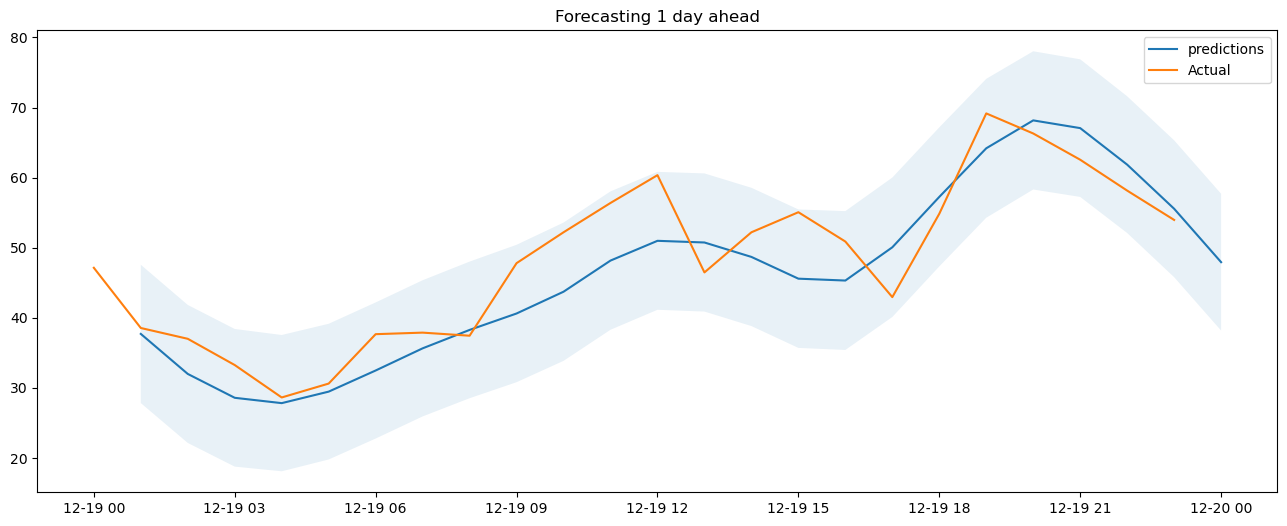

In [15]:
# Define the prediction dataframe
df = model.predict('MT_020', '2014-12-19 01:00:00', '2014-12-20  00:00:00')
# Set the figure size
plt.figure(figsize = (16, 6))
plt.plot( df['Mean Predictions'], label = 'predictions')
plt.fill_between(df.index, df['Lower Bound'], df['Upper Bound'], alpha = 0.1)
plt.plot(test_data['MT_020'].iloc[:len(df['Mean Predictions'])], label = 'Actual', alpha = 1.0)
# Set the title of the plot
plt.title('Forecasting 1 day ahead')
plt.legend()
plt.show()

**🔬 Observations**

1. **Overall trend captured well**  
   The model successfully captures the general daily electricity consumption pattern. Load values gradually increase from the early morning hours, peak in the evening (around 19:00–21:00), and then decline toward midnight. The predicted mean values follow this overall trend closely.

2. **Most actual values fall within the prediction interval**  
   The majority of the actual observations fall within the predicted confidence interval (between the lower and upper bounds). This indicates that the model provides reasonable uncertainty estimates for the forecasted values.

3. **Underestimation during early morning hours**  
   During the early morning period (01:00–04:00), the model tends to underestimate electricity consumption, as the actual values are noticeably higher than the mean predictions.

4. **Good alignment during midday hours**  
   Between 10:00 and 16:00, the predicted values align relatively closely with the actual observations, indicating that the model captures midday demand patterns effectively.

5. **Larger deviation during evening peak hours**  
   Some discrepancies appear during evening peak demand, particularly around 18:00–19:00, where the model slightly overestimates the load compared to the actual consumption.

6. **Accurate prediction near the end of the day**  
   From 20:00 onward, the predictions track the actual consumption more closely, correctly reflecting the declining load pattern toward midnight.

7. **Prediction intervals widen during peak demand periods**  
   The forecast intervals become slightly wider during high-demand hours, reflecting increased uncertainty when predicting peak electricity consumption.

#### **2. Change the Confidence**

Produce the predictions with a 99.9% confidence using the confidence parameter of the predict function.

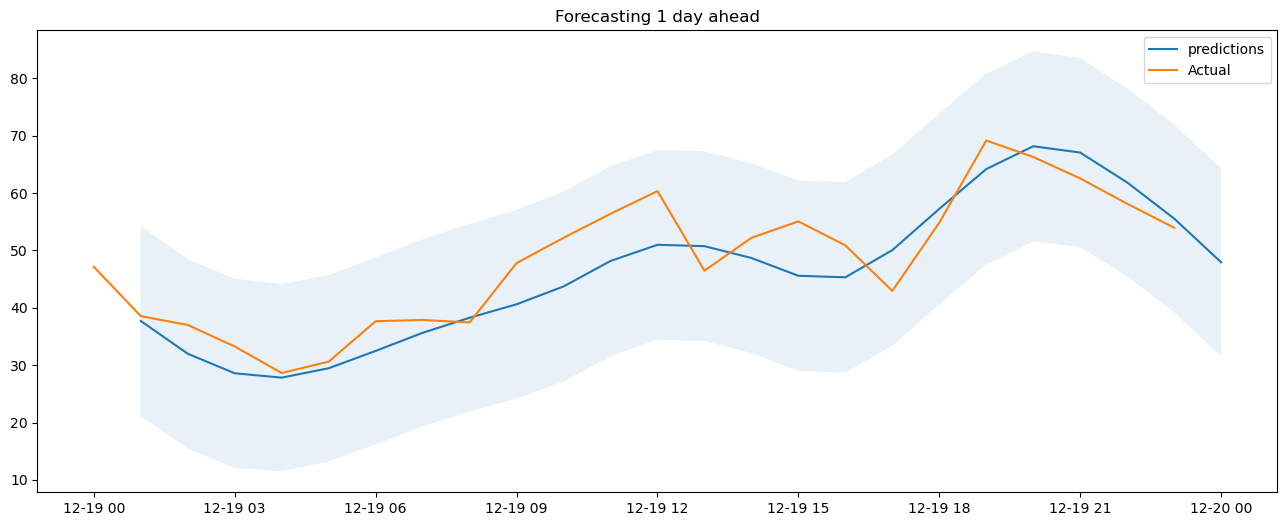

In [16]:
# Define the prediction dataframe
df = model.predict('MT_020', '2014-12-19 01:00:00', '2014-12-20  00:00:00', confidence = 99.9)
# Set the figure size
plt.figure(figsize = (16, 6))
plt.plot( df['Mean Predictions'], label = 'predictions')
plt.fill_between(df.index, df['Lower Bound'], df['Upper Bound'], alpha = 0.1)
plt.plot(test_data['MT_020'].iloc[:len(df['Mean Predictions'])], label = 'Actual', alpha = 1.0)
# Set the title of the plot
plt.title('Forecasting 1 day ahead')
plt.legend()
plt.show()

In [17]:
comparison = df.copy()
comparison['Actual'] = test_data['MT_020'].iloc[:len(df['Mean Predictions'])].values

print(comparison)

                     Mean Predictions  Lower Bound  Upper Bound     Actual
2014-12-19 01:00:00         37.703653    21.140915    54.266392  47.136564
2014-12-19 02:00:00         31.991807    15.465880    48.517735  38.546256
2014-12-19 03:00:00         28.586175    12.102400    45.069950  37.004405
2014-12-19 04:00:00         27.824963    11.502640    44.147287  33.259912
2014-12-19 05:00:00         29.467762    13.214984    45.720541  28.634361
2014-12-19 06:00:00         32.482577    16.182452    48.782701  30.616740
2014-12-19 07:00:00         35.643822    19.334671    51.952973  37.665198
2014-12-19 08:00:00         38.272723    21.910605    54.634841  37.885463
2014-12-19 09:00:00         40.614976    24.160048    57.069904  37.444934
2014-12-19 10:00:00         43.723013    27.163015    60.283011  47.797357
2014-12-19 11:00:00         48.165761    31.592522    64.738999  52.202643
2014-12-19 12:00:00         50.984939    34.468579    67.501299  56.387665
2014-12-19 13:00:00      

**🔬 Observations**

1. **Daily load pattern is captured effectively**  
   The forecast follows the typical daily electricity consumption pattern. Demand starts relatively low during early morning hours, gradually increases throughout the day, peaks in the evening (around 19:00–21:00), and declines again toward midnight. The predicted mean values closely track this overall trend.

2. **Actual values fall within the prediction interval**  
   All observed electricity consumption values fall within the predicted confidence interval (between the lower and upper bounds). This indicates that the model provides reliable uncertainty estimates for the forecasts.

3. **Underestimation in early morning hours**  
   Between 01:00 and 04:00, the model tends to slightly underestimate consumption, as the actual values are consistently higher than the predicted mean.

4. **Reasonable alignment during midday**  
   From approximately 10:00 to 16:00, the predicted mean values align relatively well with the actual observations, suggesting that the model captures daytime consumption behavior effectively.

5. **Overestimation during early evening peak**  
   Around 18:00–19:00, the model predicts higher electricity demand than observed, indicating a tendency to overestimate the evening peak load.

6. **Accurate prediction near the end of the day**  
   From 20:00 onward, the predictions become closer to the actual values, correctly capturing the declining demand pattern as the day ends.

7. **Wider prediction intervals**  
   Compared to earlier results, the prediction intervals are wider, reflecting greater uncertainty in the forecasts while still successfully covering the actual observations.

#### **3. Forecast Hourly Data for All Clients for the Next Seven Days**

Now, we will do a more quantitative test by forecasting the next seven days using a rolling window approach. Specifically, we will forecast the next seven days one day at a time for all 20 houses. Note that between forecasts, `we will incrementally train the data on the already predicted timeframe`.

In [18]:
# Initialize prediction array
predictions = np.zeros((len(test_data.columns), 24*7))
upper_bound = np.zeros((len(test_data.columns), 24*7))
lower_bound = np.zeros((len(test_data.columns), 24*7))
actual = test_data.values[ :24 * 7, : ]
# Specify start time
start_time = pd.Timestamp('2014-12-19 01:00:00')
# Predict for seven days
days = 7

for day in range(days):
    # Get the final timestamp in the day
    end_time = start_time + pd.Timedelta(hours = 23)
    # Convert timestamps to string
    start_str = start_time.strftime('%Y-%m-%d %H:%M:%S')
    end_str = end_time.strftime('%Y-%m-%d %H:%M:%S')
    # Predict for each house
    for i, column in enumerate(test_data.columns):
        # Let us create the forecast
        df_30 = model.predict(column, start_str, end_str)
        predictions[i, day * 24 : (day + 1) * 24] = df_30['Mean Predictions']
        upper_bound[i, day * 24 : (day + 1) * 24] = df_30['Upper Bound']
        lower_bound[i, day * 24 : (day + 1) * 24] = df_30['Lower Bound']

    # Fit the model with the already predicted values
    df_insert = test_data.iloc[day * 24 : 24 * (day + 1), : ]
    # Update the model
    model.update_model(df_insert)
    # Update start_time
    start_time = start_time + pd.Timedelta(hours = 24)

/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(
/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(
/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(
/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(
/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(
/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future ver

In [19]:
Y = actual[ :, : ]
Y_h = predictions.T[ :, : ]
mse = np.sqrt(np.mean(np.square(Y - Y_h)))
print ('Forecasting accuracy (RMSE):', mse)

Forecasting accuracy (RMSE): 27.921274055416855


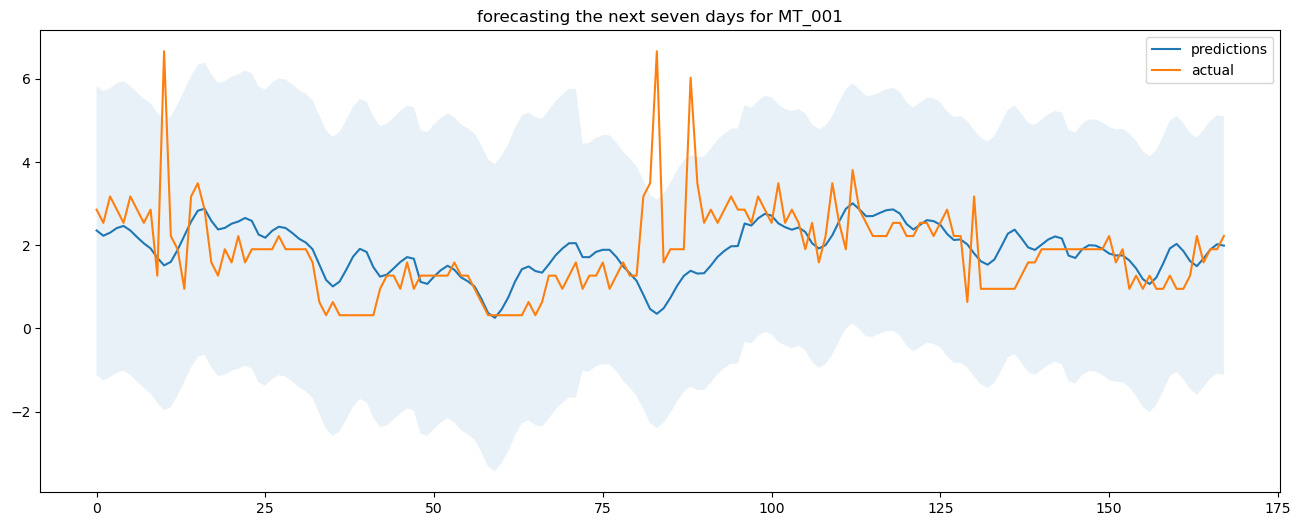

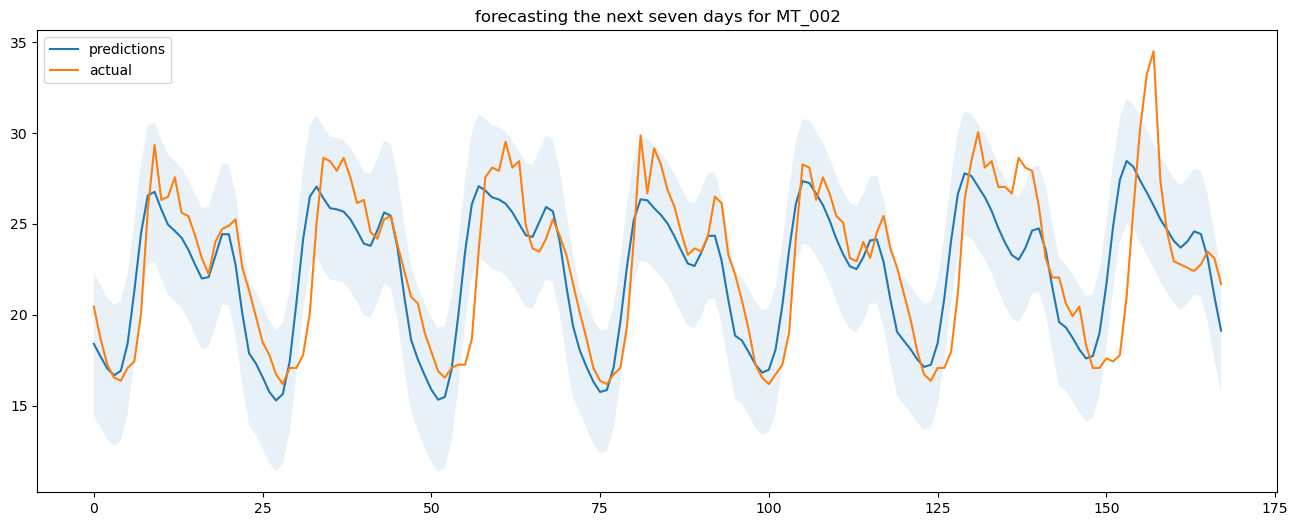

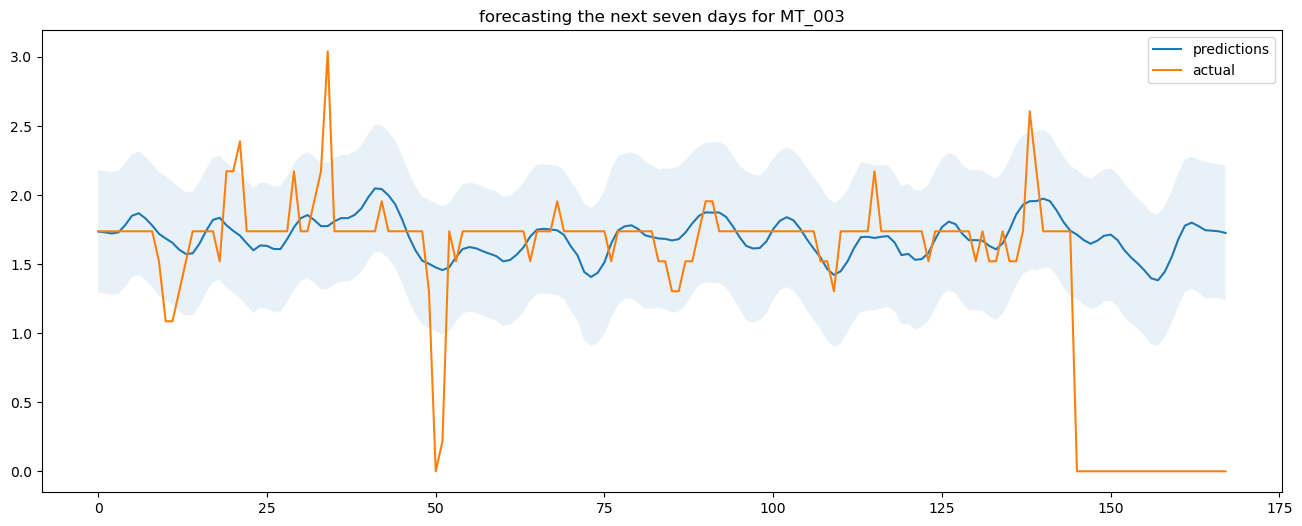

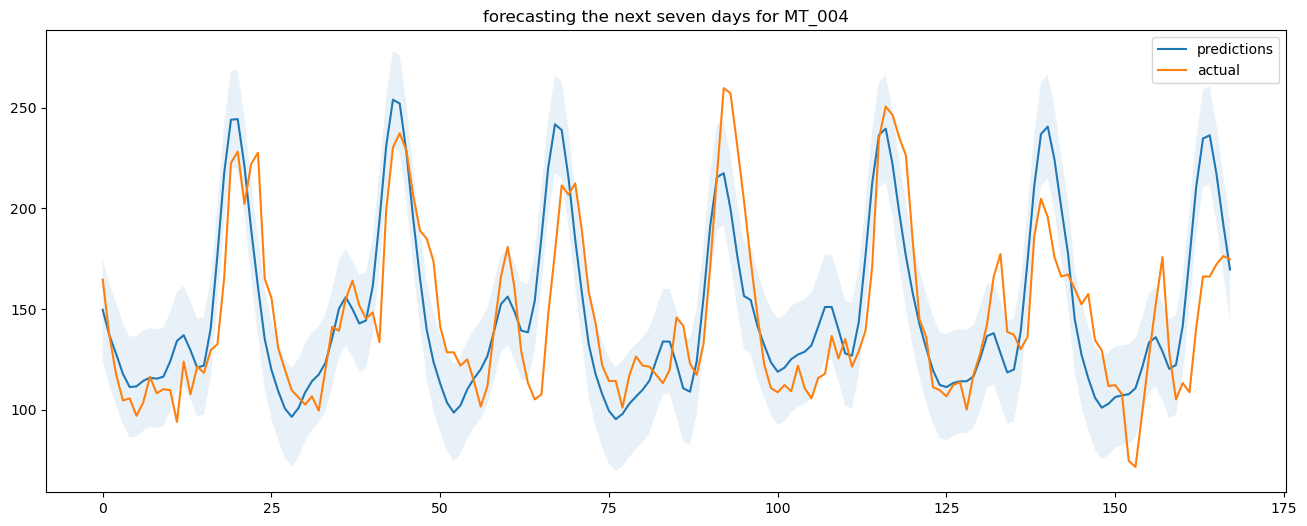

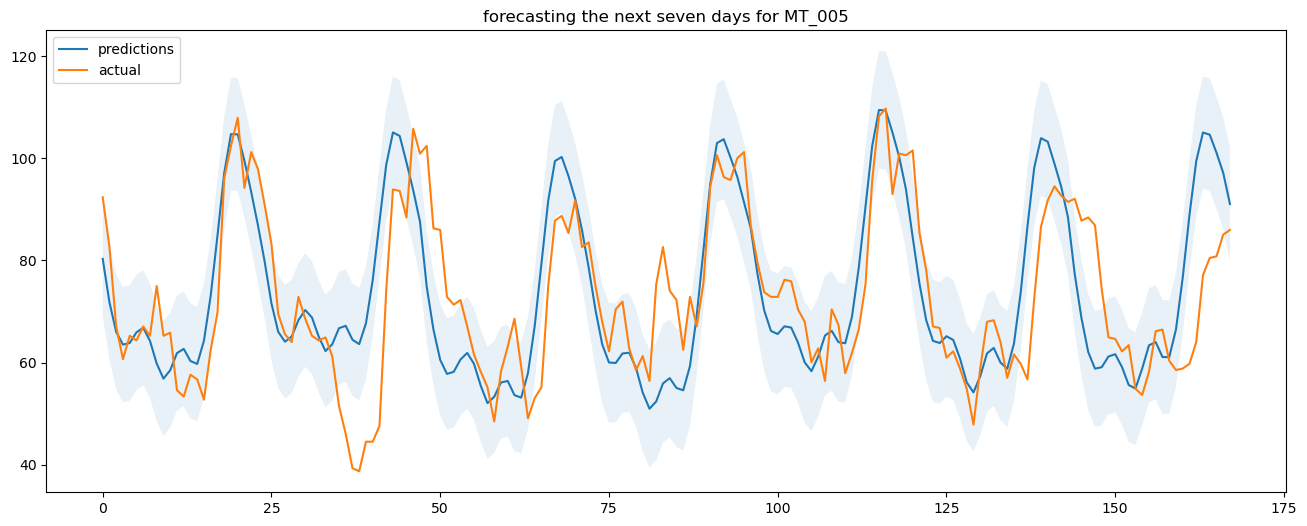

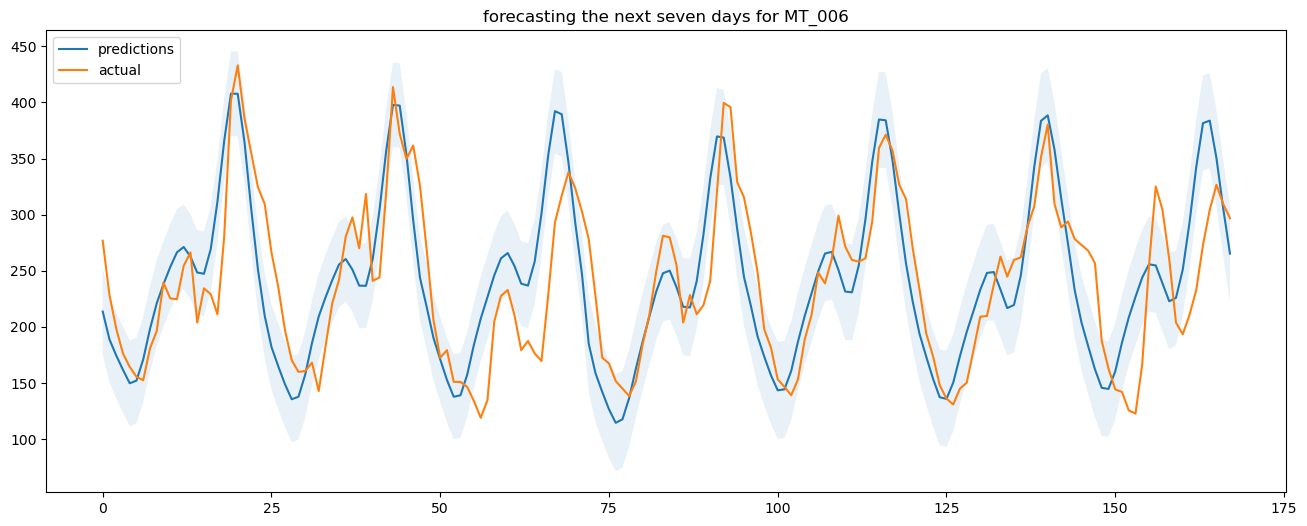

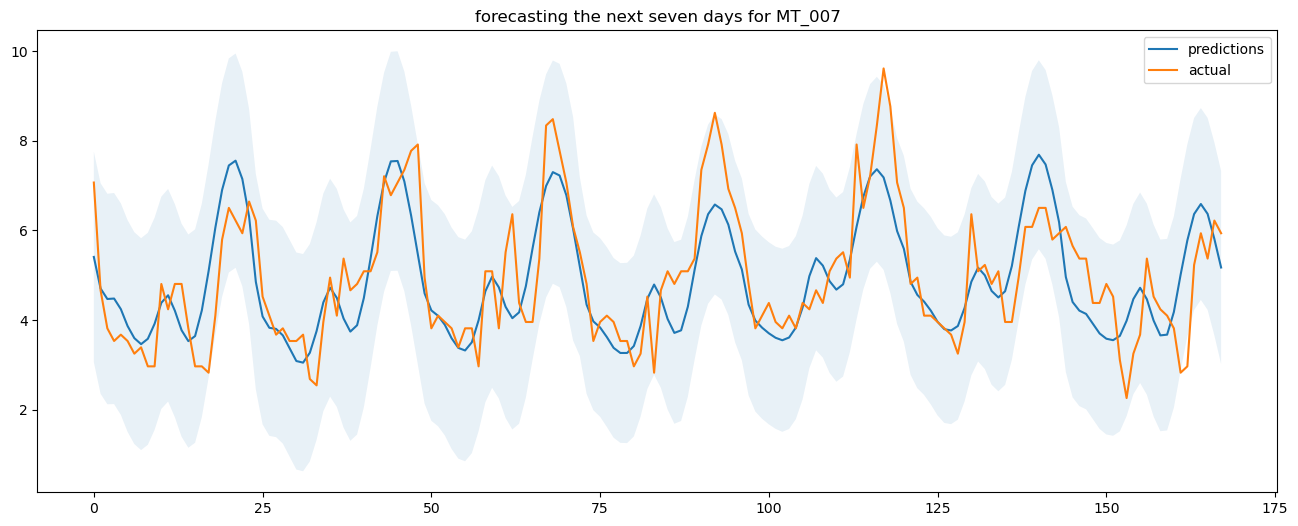

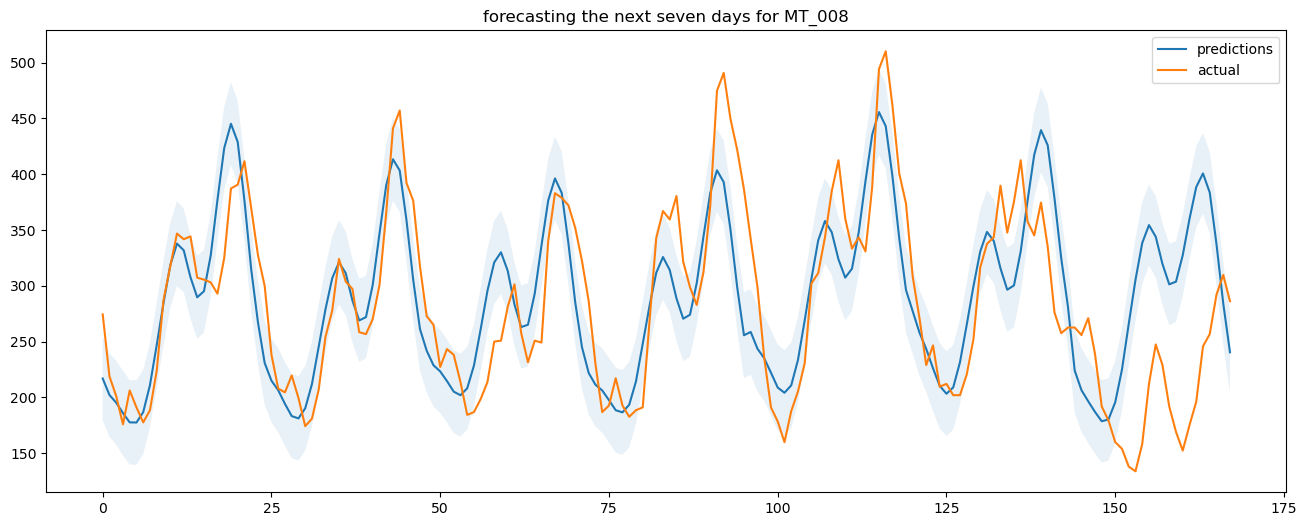

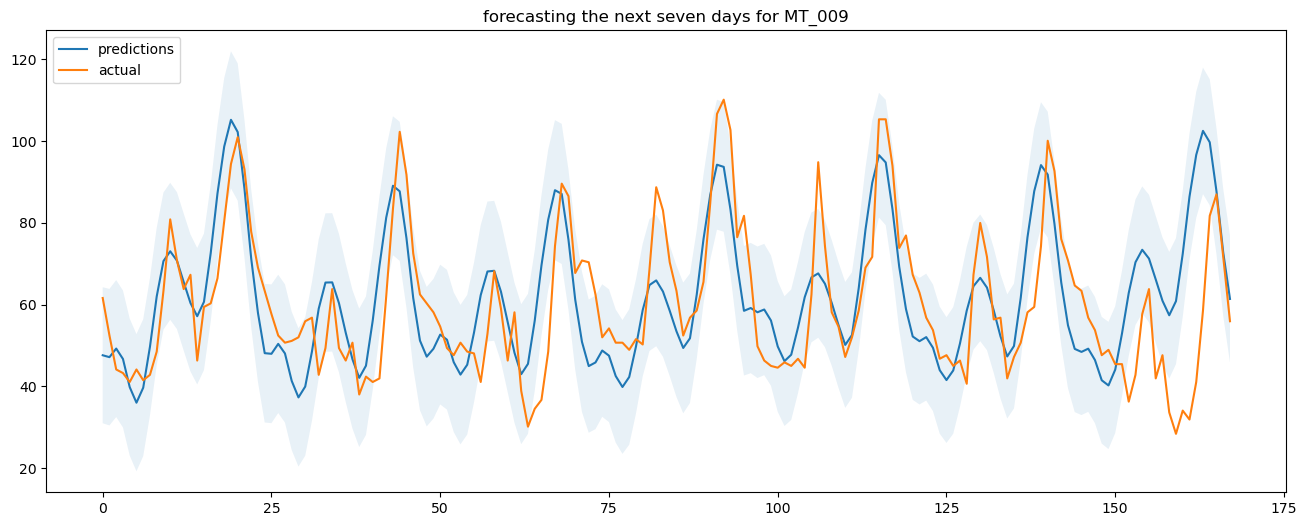

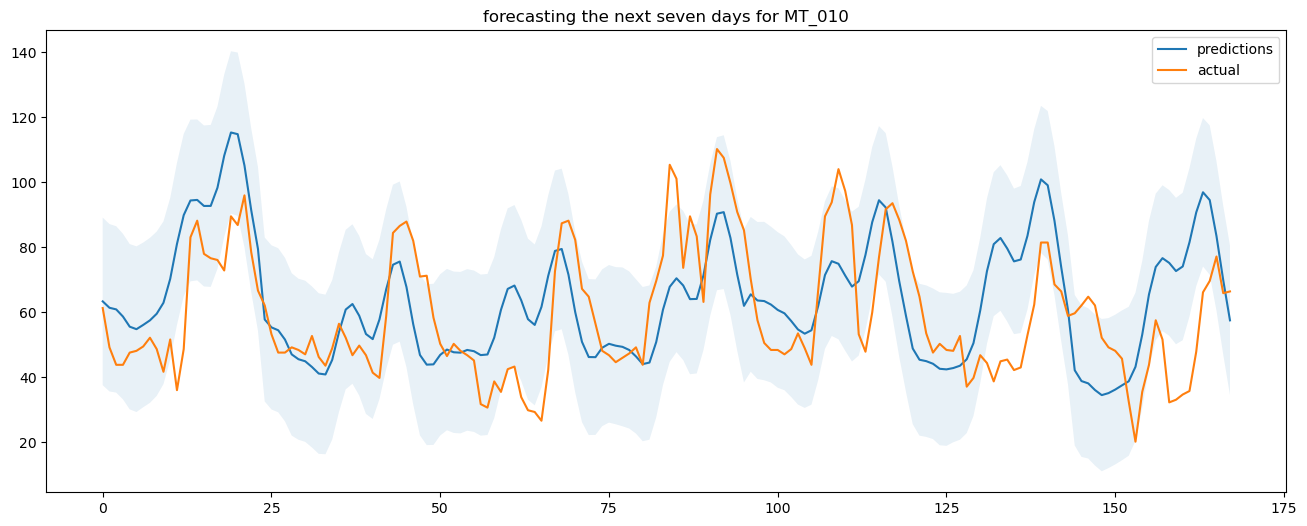

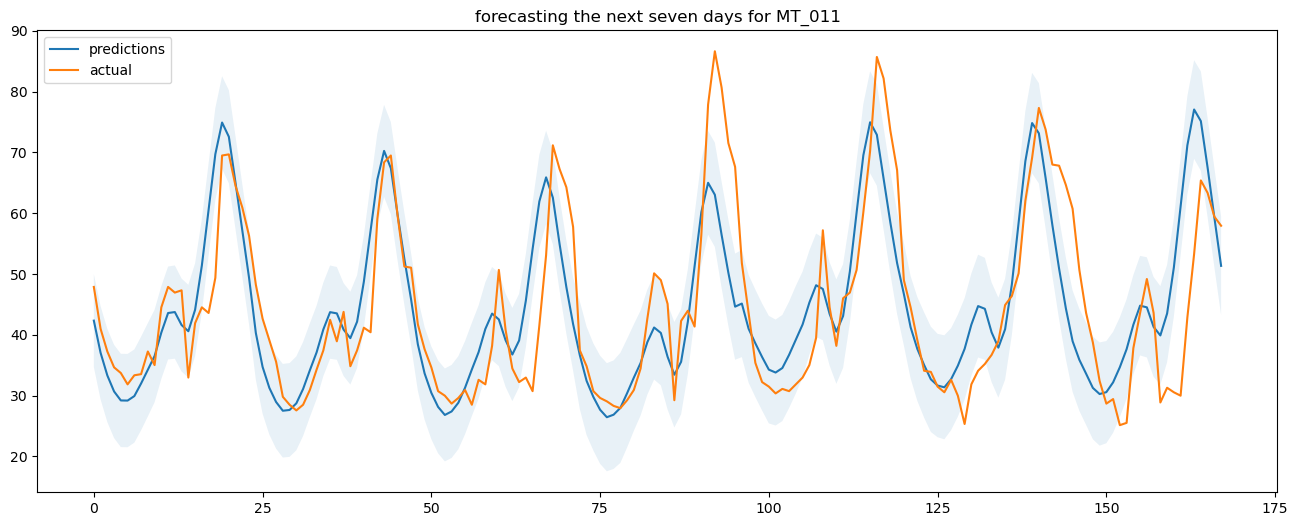

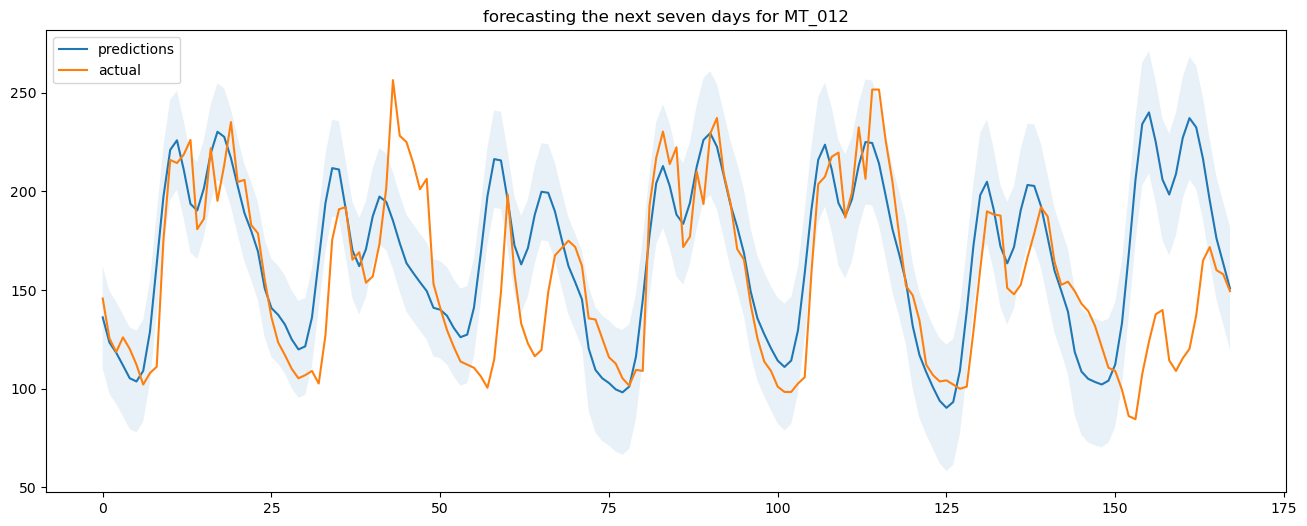

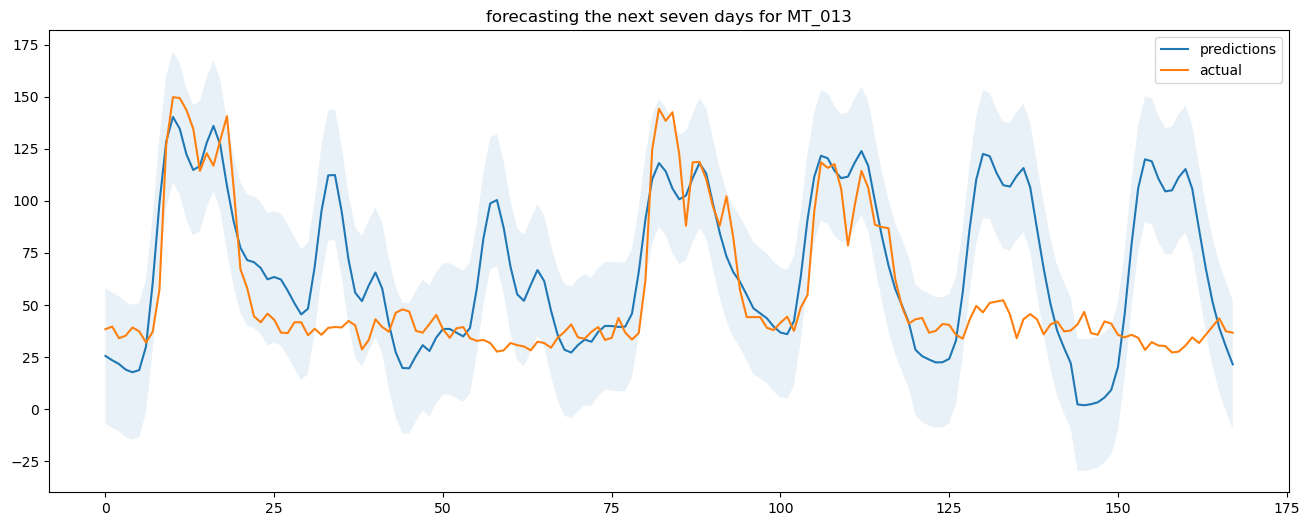

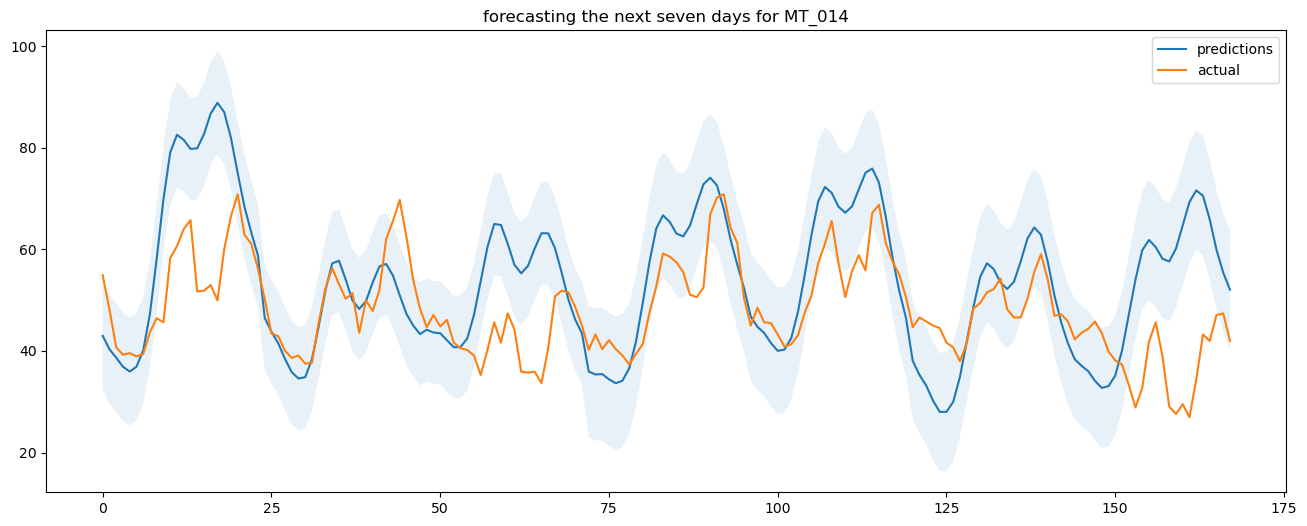

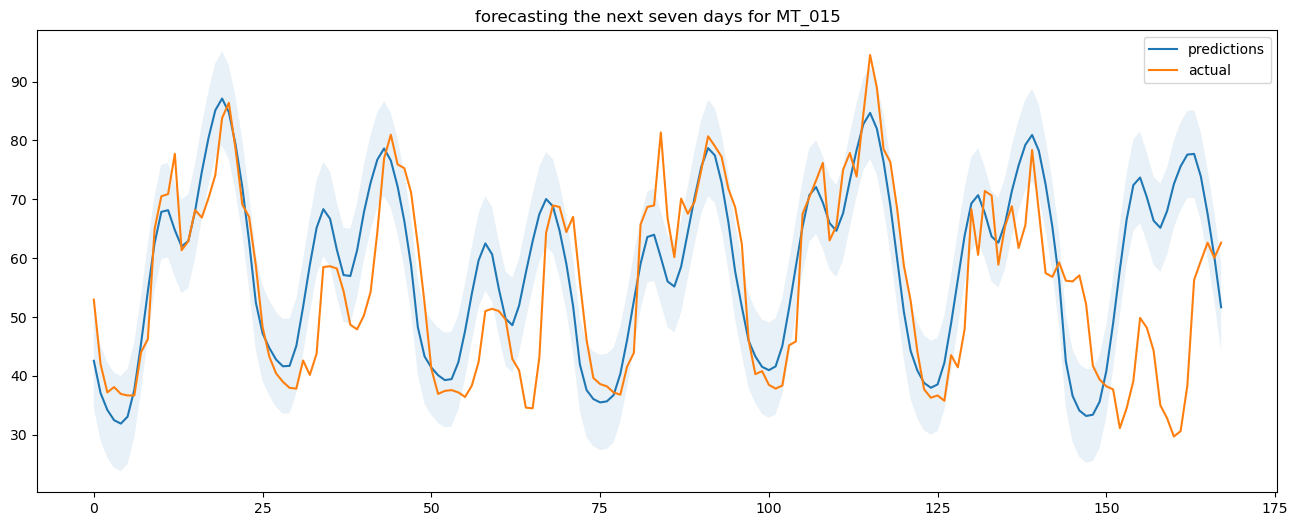

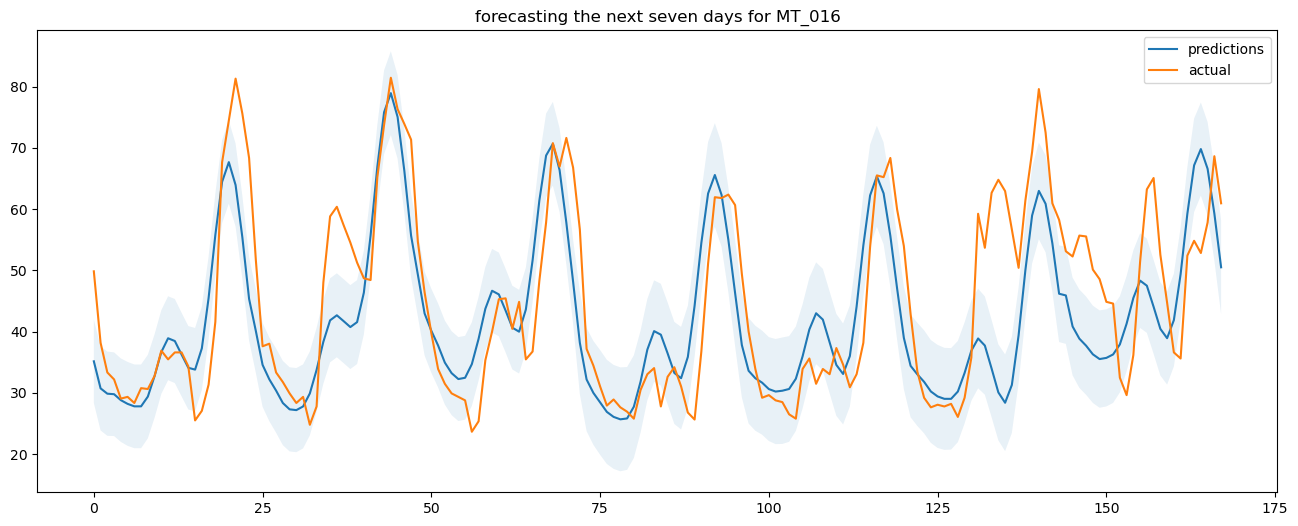

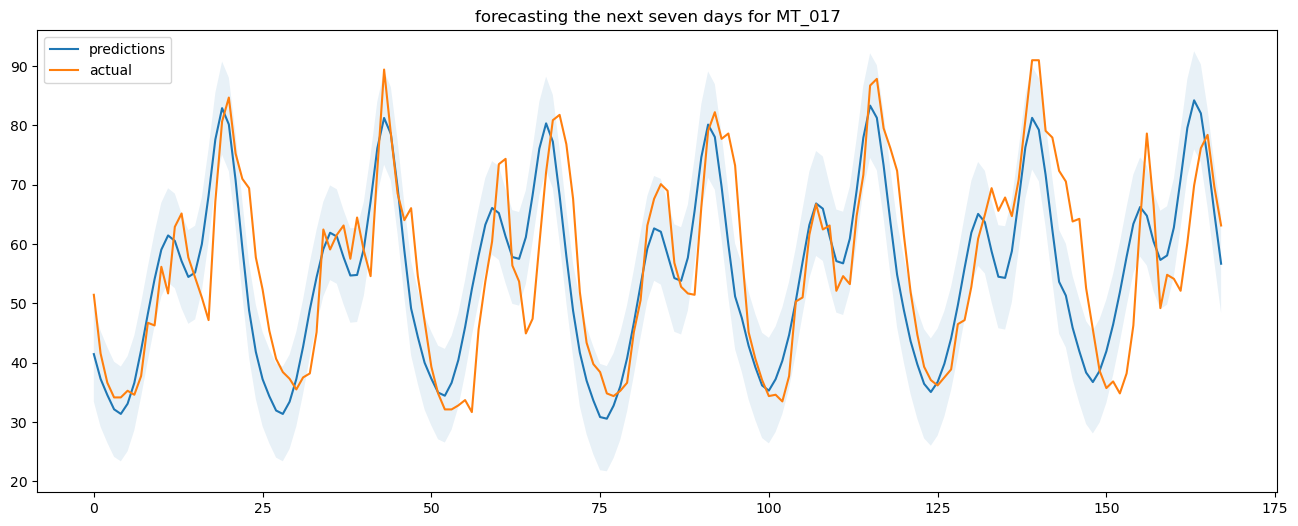

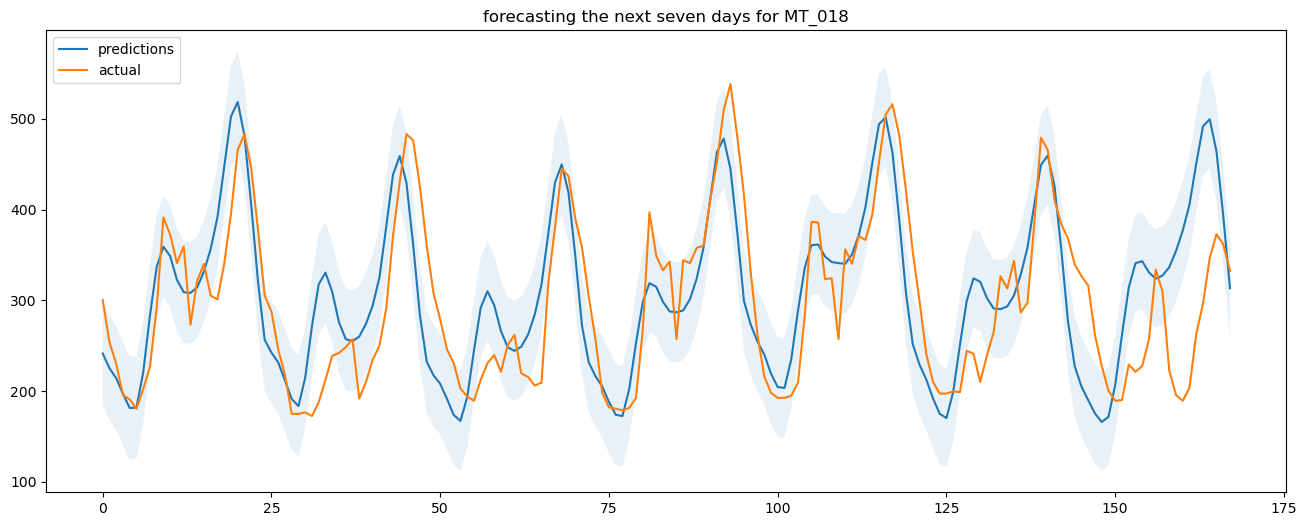

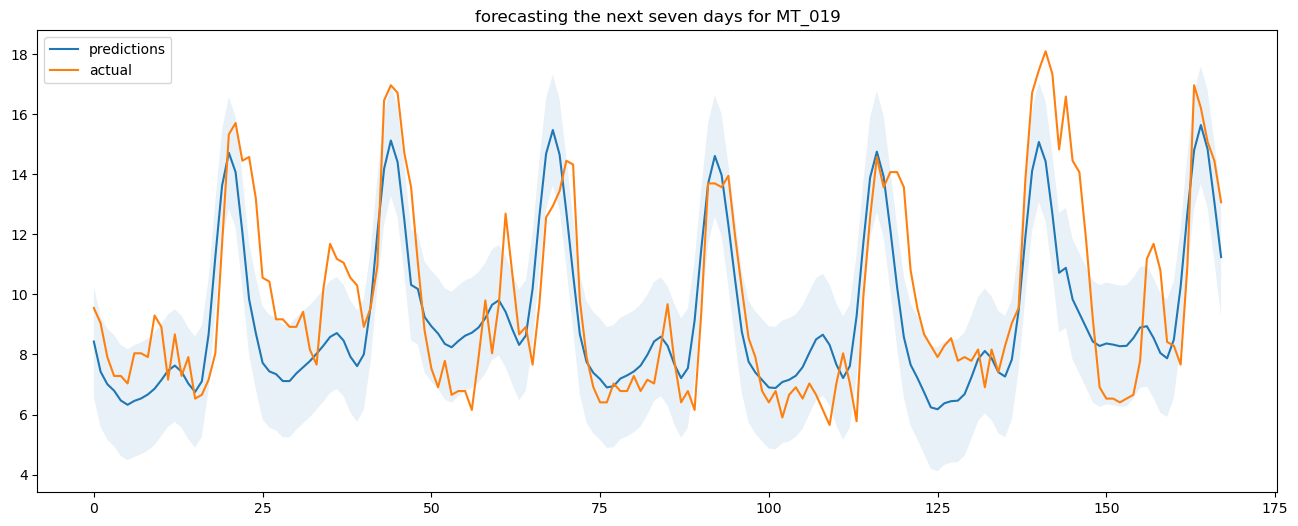

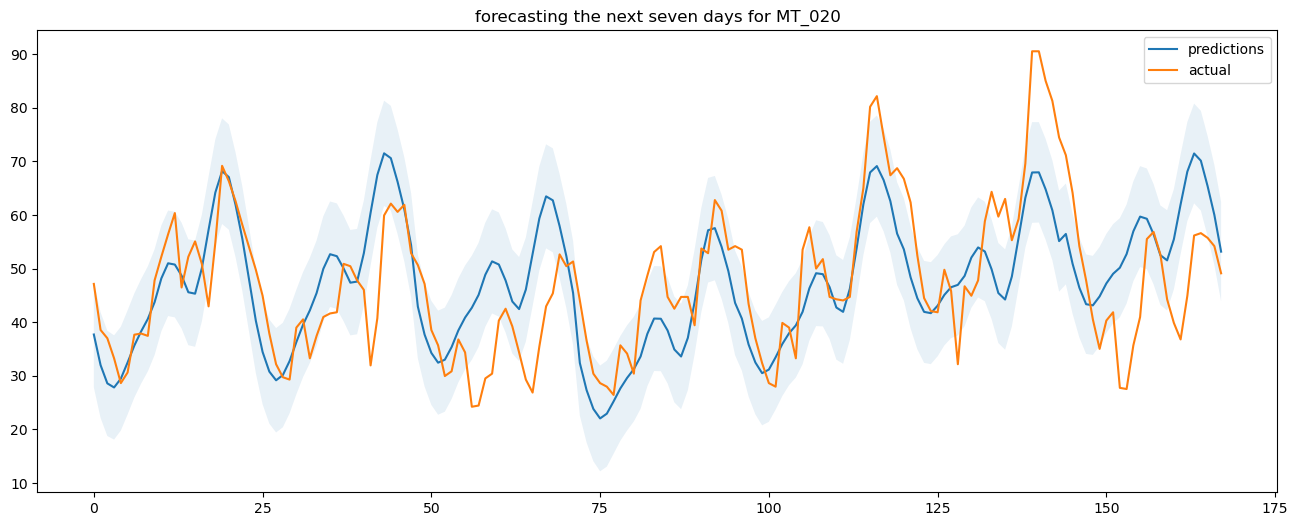

In [20]:
for i in range(20):

    # Set the figure size
    plt.figure(figsize = (16, 6))
    # Set the title
    plt.title('forecasting the next seven days for %s'%test_data.columns[i])
    plt.plot(predictions[ i, : 24 * 7], label = 'predictions')
    plt.fill_between(np.arange(24 * 7), lower_bound[ i, : 24 * 7], upper_bound[i, : 24 * 7], alpha = 0.1)
    plt.plot(actual[: 24 * 7, i ], label = 'actual')
    plt.legend()
plt.show()

**🔬 Observations**

1. **Daily consumption patterns are generally captured**
   Across most clients, the predicted mean values follow the same general temporal pattern as the actual electricity usage. The model captures the rise in demand during active hours and the reduction during off-peak periods, suggesting that the forecasting model has learned the underlying daily consumption cycle.

2. **Prediction intervals typically cover the actual observations**
   For the majority of clients (e.g., MT_002, MT_007, MT_011, MT_019, MT_020), the actual values fall within the lower and upper prediction bounds. This indicates that the model’s uncertainty estimation is reasonable and that the prediction intervals are wide enough to accommodate natural variability in electricity usage.

3. **Small-load clients show relatively stable predictions**
   Clients with lower electricity consumption levels (such as MT_001, MT_003, and MT_019) display smaller fluctuations in both predictions and actual values. In these cases, the forecasts remain relatively close to the observed values, suggesting that lower-variance consumption patterns are easier for the model to predict.

4. **Higher-consumption clients exhibit larger deviations**
   Clients with higher electricity usage (e.g., MT_004, MT_006, MT_008, MT_012, and MT_018) show larger gaps between predicted means and actual consumption. While the overall trend is still captured, peak loads are sometimes significantly overestimated or underestimated, indicating that high-demand clients introduce more volatility into the forecasting task.

5. **Occasional overestimation during peak periods**
   In several cases (e.g., MT_004, MT_006, MT_008, MT_018), the model predicts higher consumption during peak periods than what is observed in the actual data. This suggests that the model may slightly exaggerate peak demand when strong historical patterns exist.

6. **Wide prediction intervals for high-variance clients**
   Clients with larger consumption ranges tend to have wider prediction intervals. This reflects increased uncertainty when forecasting high-magnitude loads and suggests that the model appropriately adjusts its confidence range based on historical variability.

7. **Anomalies or zero consumption values appear in some clients**
   For example, MT_003 shows periods where actual consumption drops to zero while the model continues predicting a baseline load. This may indicate either missing data, inactive clients, or newly introduced customers whose historical usage pattern differs from the training distribution.

8. **Overall model performance**
   The forecasting model performs well at capturing the **general shape and scale of electricity demand** across multiple clients, but deviations increase for **high-consumption or highly volatile clients**, indicating potential areas for improvement such as client-specific models or additional temporal features.

## **IV. Conclusion**

For the 20 different time series predictions on the **test dataset**, the model performs well for most clients. The predicted values generally follow the overall trend of the actual electricity consumption.

However, the model shows weaker performance for a few series, particularly **MT_003, MT_013, and MT_014**. One possible reason is that these time series appear to be **noisier and less consistent** than the others.

For example, in **MT_003**, the electricity consumption drops to **zero on certain days**, which is unusual and likely indicates missing data, anomalies, or inactive periods. Such irregular patterns make it more difficult for the model to learn stable consumption behavior and produce accurate forecasts.

To further improve the model’s performance on these challenging time series, several steps can be taken:

- **Data cleaning and investigation:** First examine the data to understand the source of the noisy or irregular observations and address issues such as anomalies, missing values, or incorrect measurements.  
- **Hyperparameter optimization:** Improve model performance by tuning key algorithm parameters through techniques such as grid search (e.g., optimizing *rank*, *gamma*, *col_to_row_ratio*, *L*, etc.).

### **i. Impute missing values**

In [21]:
# Create the copy of the original time series
final_ts = pd.DataFrame(final_data['MT_001'].loc['2014-01-01 01:00:00':'2014-01-08 01:00:00']).copy()

Create missing values randomly in `20%` of the observations, save them in a different variable and create a pandas data frame from it.

In [22]:
# Creat a time series with missing values
ts_with_missing_values = final_data['MT_001'].loc['2014-01-01 01:00:00':'2014-01-08 01:00:00']
ts_with_missing_values.loc[ts_with_missing_values.sample(frac = 0.2).index] = np.nan
ts_with_missing_values = ts_with_missing_values.rename('MT_001_with_missing_values')
ts_with_missing_values = pd.DataFrame(ts_with_missing_values).reset_index()

Plot the time series and see how it looks like:

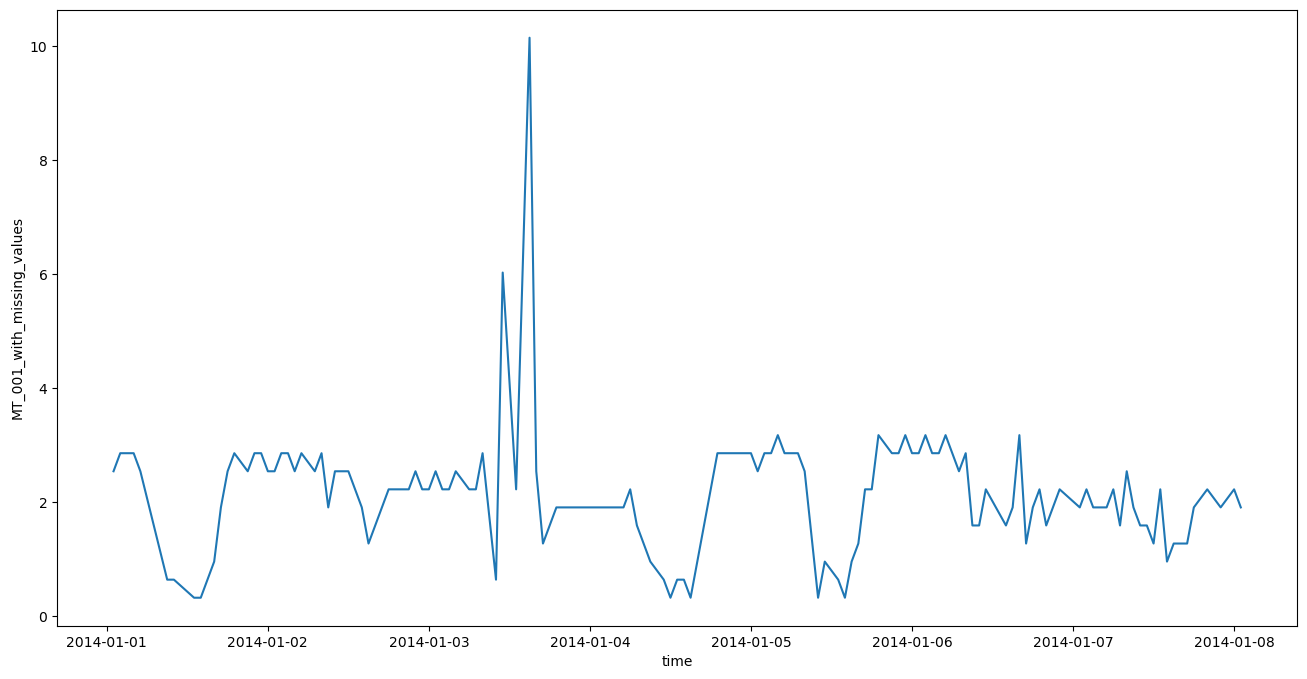

In [23]:
# Creating the plot

# Fix the figure size
figure = plt.figure(figsize = (16, 8))

# Creating the line plot
sns.lineplot(data = ts_with_missing_values,
             x = 'time',
             y = 'MT_001_with_missing_values');

Build the model and pass the time series with missing values into it.

In [24]:
# Time series with missing vlaues
ts_with_missing_values = ts_with_missing_values.set_index('time')

Build the model with the same rank that we used above, i.e., 20.

In [25]:
model_for_missing_values = mSSA(rank = 20)
# Update the model
model_for_missing_values.update_model(ts_with_missing_values)

/opt/anaconda3/lib/python3.13/site-packages/mssa/mssa.py:156: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  pd.Grouper(


We are predicting the values for the entire time series. We will provide the prediction for missing values in that time series.

In [26]:
imputed_predictions = model_for_missing_values.predict('MT_001_with_missing_values', '2014-01-01 01:00:00', '2014-01-08 01:00:00')

Now, let's create another dataset, containing three-time series:
- Time series with missing values
- Time-series predictions by the model and
- The original time series from the dataset without missing values

In [27]:
# Combine the data
combined_data = pd.concat([ts_with_missing_values, imputed_predictions, final_ts['MT_001'].loc['2014-01-01':'2014-01-08']],
                          axis = 1)
combined_data = combined_data.reset_index()

Let's plot these three-time series to compare the predicted missing values against the original values in the time series.

### **ii. The Original Series**

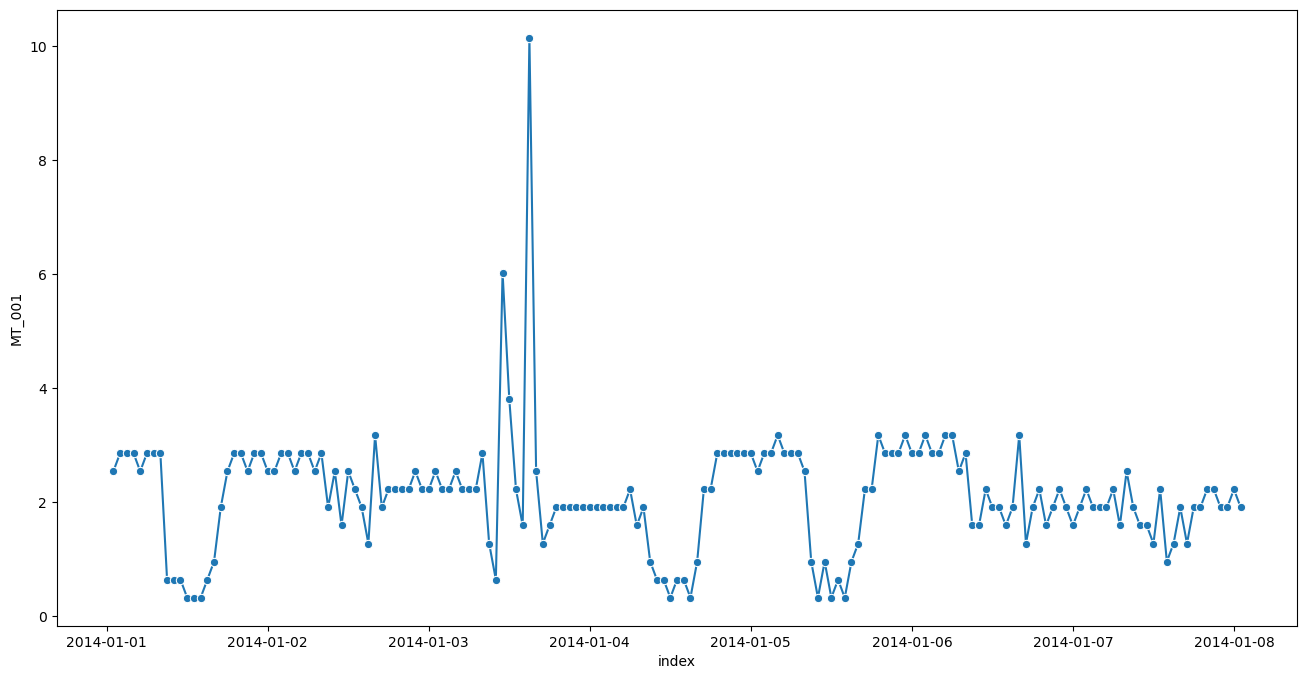

In [28]:
# Create the plot
figure = plt.figure(figsize = (16, 8))
sns.lineplot(data = combined_data,
             x = 'index',
             y = 'MT_001',
             marker = 'o');

### **iii. The Series with Missing Values**

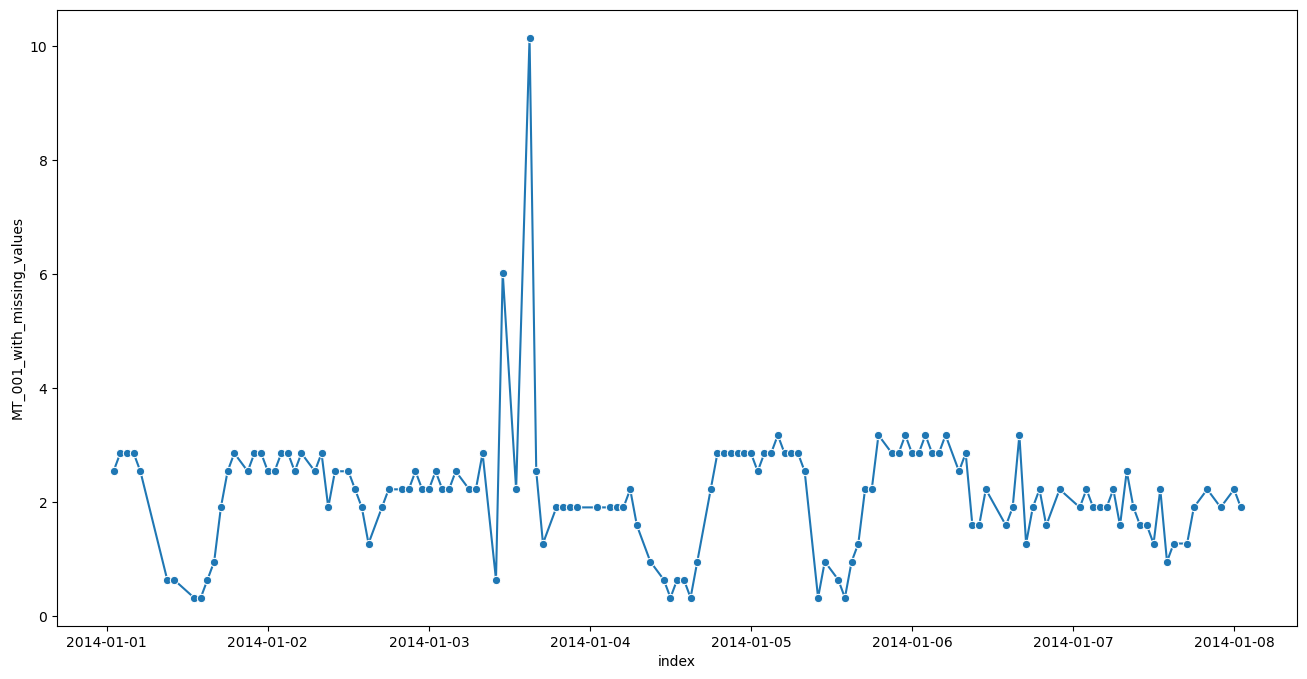

In [29]:
# Create the plot
# Set the figure size
figure = plt.figure(figsize = (16, 8))

# Creating the line plot using seaborn library
sns.lineplot(data = combined_data,
             x = 'index',
             y = 'MT_001_with_missing_values',
             marker = 'o');

### **iv. The Predicted Series**

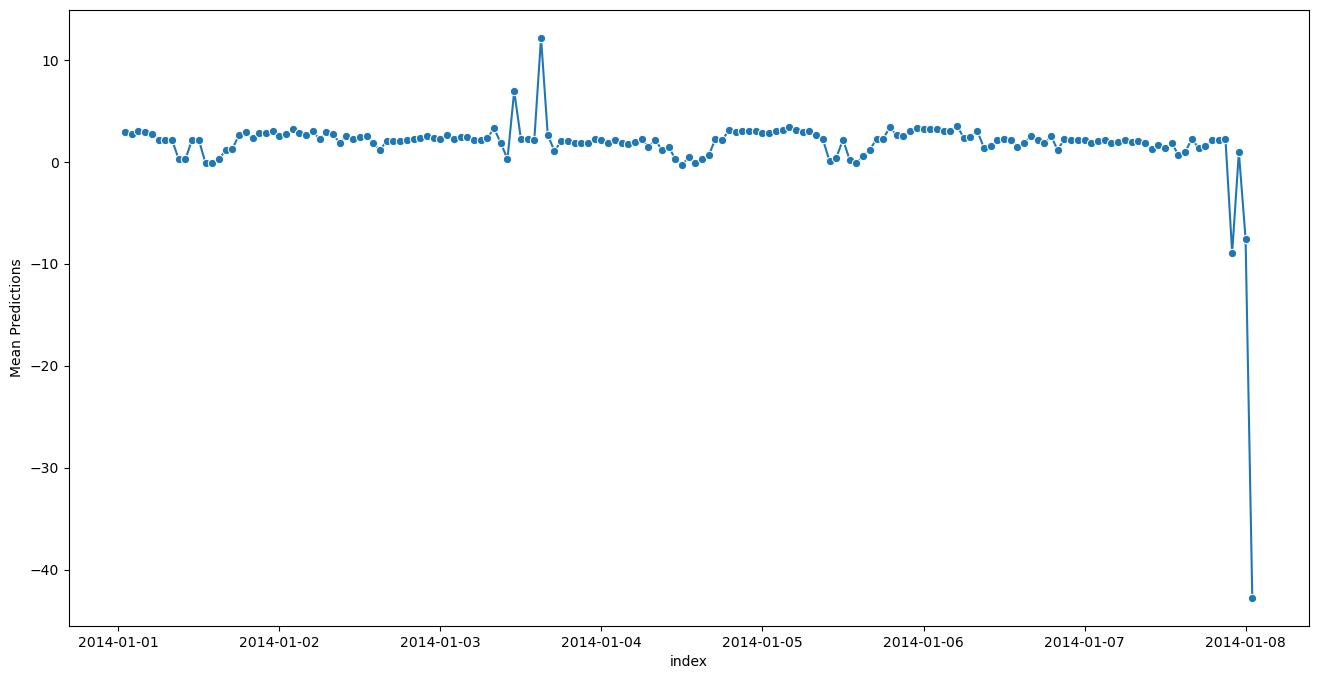

In [30]:
figure = plt.figure(figsize = (16, 8))

sns.lineplot(data = combined_data,
             x = 'index',
             y = 'Mean Predictions',
             marker = 'o');